# 4.4 Analisi con Pandas 
### 1. Importare da SQL o usare dataframe pulito


In [64]:
#Importazione librerie necessarie

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium

In [18]:
#Aggregazione di tutte tabelle con join su colonne in comune per ottenere un unico db da sql e caricamento su visual studio

# 1. Definizione dell'engine
engine = create_engine('mysql+pymysql://root:@127.0.0.1:3306/Hotel_Reviews')

# Query
query = """
SELECT * 
FROM Reviews 
JOIN Hotels ON Reviews.Hotel_ID = Hotels.Hotel_ID
JOIN Reviewers ON Reviews.Reviewer_ID = Reviewers.Reviewer_ID
JOIN Hotel_Stats ON Hotels.Hotel_ID = Hotel_Stats.Hotel_ID
"""
HR1 = pd.read_sql(query, engine)
HR1.info()


<class 'pandas.DataFrame'>
RangeIndex: 511944 entries, 0 to 511943
Data columns (total 28 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Review_ID                          511944 non-null  str    
 1   Review_Date                        511944 non-null  object 
 2   Negative_Review                    511944 non-null  str    
 3   Review_Total_Negative_Word_Counts  511944 non-null  int64  
 4   Positive_Review                    511944 non-null  str    
 5   Review_Total_Positive_Word_Counts  511944 non-null  int64  
 6   Reviewer_Score                     511944 non-null  float64
 7   Tags                               511944 non-null  str    
 8   Year                               511944 non-null  int64  
 9   Month                              511944 non-null  int64  
 10  Hotel_ID                           511944 non-null  str    
 11  Reviewer_ID                        511944 non-null

In [19]:
#Creazione di una copia per apportare variazioni e cancellazione delle colonne dupplicate in essa

HR_c_sql = HR1.copy()
HR_c_sql = HR_c_sql.loc[:, ~HR_c_sql.columns.duplicated()]
HR_c_sql.info()



<class 'pandas.DataFrame'>
RangeIndex: 511944 entries, 0 to 511943
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Review_ID                          511944 non-null  str    
 1   Review_Date                        511944 non-null  object 
 2   Negative_Review                    511944 non-null  str    
 3   Review_Total_Negative_Word_Counts  511944 non-null  int64  
 4   Positive_Review                    511944 non-null  str    
 5   Review_Total_Positive_Word_Counts  511944 non-null  int64  
 6   Reviewer_Score                     511944 non-null  float64
 7   Tags                               511944 non-null  str    
 8   Year                               511944 non-null  int64  
 9   Month                              511944 non-null  int64  
 10  Hotel_ID                           511944 non-null  str    
 11  Reviewer_ID                        511944 non-null

In [20]:
# controllo dei duplicati
HR_c_sql.duplicated().sum()
#controllo dei valori nulli
HR_c_sql.isnull().sum()


Review_ID                            0
Review_Date                          0
Negative_Review                      0
Review_Total_Negative_Word_Counts    0
Positive_Review                      0
Review_Total_Positive_Word_Counts    0
Reviewer_Score                       0
Tags                                 0
Year                                 0
Month                                0
Hotel_ID                             0
Reviewer_ID                          0
Hotel_Name                           0
Hotel_Address                        0
Hotel_Country                        0
Hotel_City                           0
Reviewer_Nationality                 0
Guest_Category                       0
Reviewer_Total_Reviews               0
Additional_Number_of_Scoring         0
Average_Score                        0
Total_Number_of_Reviews              0
days_since_review                    0
lat                                  0
lng                                  0
dtype: int64

In [74]:
#HR_c_sql.head(10)
print(HR_c_sql[['Hotel_Name', 'Hotel_Address', 'Hotel_Country', 'Hotel_City']].head(5))

#Rinomino il db con un nome più sintetico per agevolare l'inserimento nei codici 
HR = HR_c_sql
print('\nLe Colonne di HR:', HR.columns.tolist())

    Hotel_Name                                      Hotel_Address  \
0  Hotel Arena   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
1  Hotel Arena   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
2  Hotel Arena   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
3  Hotel Arena   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
4  Hotel Arena   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   

  Hotel_Country Hotel_City  
0   Netherlands  Amsterdam  
1   Netherlands  Amsterdam  
2   Netherlands  Amsterdam  
3   Netherlands  Amsterdam  
4   Netherlands  Amsterdam  

Le Colonne di HR: ['Review_ID', 'Review_Date', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Reviewer_Score', 'Tags', 'Year', 'Month', 'Hotel_ID', 'Reviewer_ID', 'Hotel_Name', 'Hotel_Address', 'Hotel_Country', 'Hotel_City', 'Reviewer_Nationality', 'Guest_Category', 'Reviewer_Total_Reviews', 'Additional_Number_of_Scoring', 'Average_Score', 'T

### 2. Riprodurre analisi SQL principali (group by mensile, ranking nazionalità, 
distribuzione città)


In [22]:
#1. Group By Mensile (Andamento temporale)
query_mensile = """
SELECT Month, COUNT(Review_ID) AS Totale_Recensioni, AVG(Reviewer_Score) AS Media_Mese
FROM Reviews
GROUP BY Month
ORDER BY Month ASC;
"""

#salvataggio con nome della versione del risultato, per renderla disponibile a eventuali futuri utilizzi
HR_mensile = pd.read_sql(query_mensile, engine)
HR_mensile.head(5)



,Month,Totale_Recensioni,Media_Mese
0,1,41828,8.48704
1,2,38176,8.52905
2,3,40868,8.48059
3,4,42612,8.43195
4,5,46187,8.38282


In [23]:
#2. Ranking Nazionalità (Chi recensisce di più)
query_nazionalita = """
SELECT Reviewers.Reviewer_Nationality, COUNT(Reviews.Review_ID) AS Num_Recensioni
FROM Reviews
JOIN Reviewers ON Reviews.Reviewer_ID = Reviewers.Reviewer_ID
GROUP BY Reviewers.Reviewer_Nationality
ORDER BY Num_Recensioni DESC
LIMIT 10; -- Prendi le prime 10 nazioni
"""

#salvataggio con nome della versione del risultato, per renderla disponibile a eventuali futuri utilizzi
HR_nazionalita_Reviwer = pd.read_sql(query_nazionalita, engine)
HR_nazionalita_Reviwer.head(5)



,Reviewer_Nationality,Num_Recensioni
0,United Kingdom,244321
1,United States of America,35108
2,Australia,21502
3,Ireland,14733
4,United Arab Emirates,10170


In [24]:
#3. Distribuzione Città 

query_citta = """
SELECT Hotels.Hotel_City, COUNT(Reviews.Review_ID) AS Recensioni_Ricevute
FROM Reviews
JOIN Hotels ON Reviews.Hotel_ID = Hotels.Hotel_ID
GROUP BY Hotels.Hotel_City
ORDER BY Recensioni_Ricevute DESC;
"""
#salvataggio con nome della versione del risultato, per renderla disponibile a eventuali futuri utilizzi
HR_City = pd.read_sql(query_citta, engine)
HR_City.head(5)


,Hotel_City,Recensioni_Ricevute
0,London,262298
1,Barcelona,59942
2,Paris,59031
3,Amsterdam,57211
4,Milan,37204


### 3. Confrontare risultati SQL vs pandas


In [25]:
#Confronto dei risultati sql con quelli ottenuti tramite pandas
#1. Raggruppamento mensile 
# Raggruppamento mensile su DataFrame Pandas
HR_mensile_pd = HR.groupby('Month').agg(
    Totale_Recensioni=('Review_ID', 'count'),
    Media_Mese=('Reviewer_Score', 'mean')
).reset_index()

#salvataggio con nome della versione del risultato
HR_mensile_pd = HR_mensile.sort_values('Month')

print(HR_mensile_pd.head(5))

   Month  Totale_Recensioni  Media_Mese
0      1              41828     8.48704
1      2              38176     8.52905
2      3              40868     8.48059
3      4              42612     8.43195
4      5              46187     8.38282


In [26]:
#2. Ranking Nazionalità 
# Raggruppamento e conteggio delle recensioni per nazionalità
HR_nazionalita = HR.groupby('Reviewer_Nationality').agg(
    Num_Recensioni=('Review_ID', 'count')
).reset_index()

# Ordinamento decrescente e selezione delle prime 10 righe
HR_nazionalita_Reviwer_pd = HR_nazionalita.sort_values('Num_Recensioni', ascending=False).head(10)

# Visualizzazione del risultato
print(HR_nazionalita_Reviwer_pd)


           Reviewer_Nationality  Num_Recensioni
214             United Kingdom           244321
216   United States of America            35108
14                   Australia            21502
98                     Ireland            14733
213       United Arab Emirates            10170
176               Saudi Arabia             8903
144                Netherlands             8691
197                Switzerland             8607
78                     Germany             7831
38                      Canada             7802


In [27]:
#3. Distribuzione Città 
HR_City_pd = HR.groupby('Hotel_City').agg(
    Recensioni_Ricevute=('Review_ID', 'count')
).reset_index().sort_values('Recensioni_Ricevute', ascending=False)

print(HR_City_pd)

  Hotel_City  Recensioni_Ricevute
2     London               262298
1  Barcelona                59942
4      Paris                59031
0  Amsterdam                57211
3      Milan                37204
5     Vienna                36258


### 4. Feature engineering: sentiment base da word counts, cluster città per score



In [28]:
# Creazione di una colonna per il Sentiment Index (da 0 a 1)
# (N.B. Più è vicino a 1, più la recensione è sbilanciata sul positivo)
HR['Sentiment_Index'] = HR['Review_Total_Positive_Word_Counts'] / (
    HR['Review_Total_Positive_Word_Counts'] + HR['Review_Total_Negative_Word_Counts'] + 1
)

# Definizione del Sentiment qualitativo
def definisci_sentiment(score):
    if score > 0.7: return 'Positive'
    if score < 0.3: return 'Negative'
    return 'Neutral'

HR['Sentiment_Label'] = HR['Sentiment_Index'].apply(definisci_sentiment)

print(HR[['Positive_Review', 'Sentiment_Index', 'Sentiment_Label']].head())

                                     Positive_Review  Sentiment_Index  \
0   Only the park outside of the hotel was beauti...         0.026895   
1   The room was big enough and the bed is good T...         0.757576   
2   beautiful surroundings great location Old wor...         0.233333   
3                                           Location         0.046512   
4   Location was ok and has access to all the pub...         0.329412   

  Sentiment_Label  
0        Negative  
1        Positive  
2        Negative  
3        Negative  
4         Neutral  


In [29]:
# Calcolo della media e deviazione standard del punteggio per ogni città
city_stats = HR.groupby('Hotel_City')['Reviewer_Score'].agg(['mean', 'std', 'count']).reset_index()

# Creazione dei Cluster in base alla media (Targeting)
def cluster_città(media):
    if media > 8.5: return 'Top Excellence'
    if media > 8.0: return 'High Quality'
    return 'Standard Service'

city_stats['Quality_Cluster'] = city_stats['mean'].apply(cluster_città)

# Ordinamento dei risultati
print(city_stats.sort_values('mean', ascending=False))

  Hotel_City      mean       std   count Quality_Cluster
5     Vienna  8.567158  1.503474   36258  Top Excellence
1  Barcelona  8.553839  1.554076   59942  Top Excellence
0  Amsterdam  8.456230  1.599051   57211    High Quality
4      Paris  8.423113  1.653648   59031    High Quality
3      Milan  8.346678  1.648622   37204    High Quality
2     London  8.324130  1.672142  262298    High Quality


# 4.5 Visualizzazioni con Matplotlib (8 grafici obbligatori) 
### 1. Line plot recensioni/mese e recensioni/anno


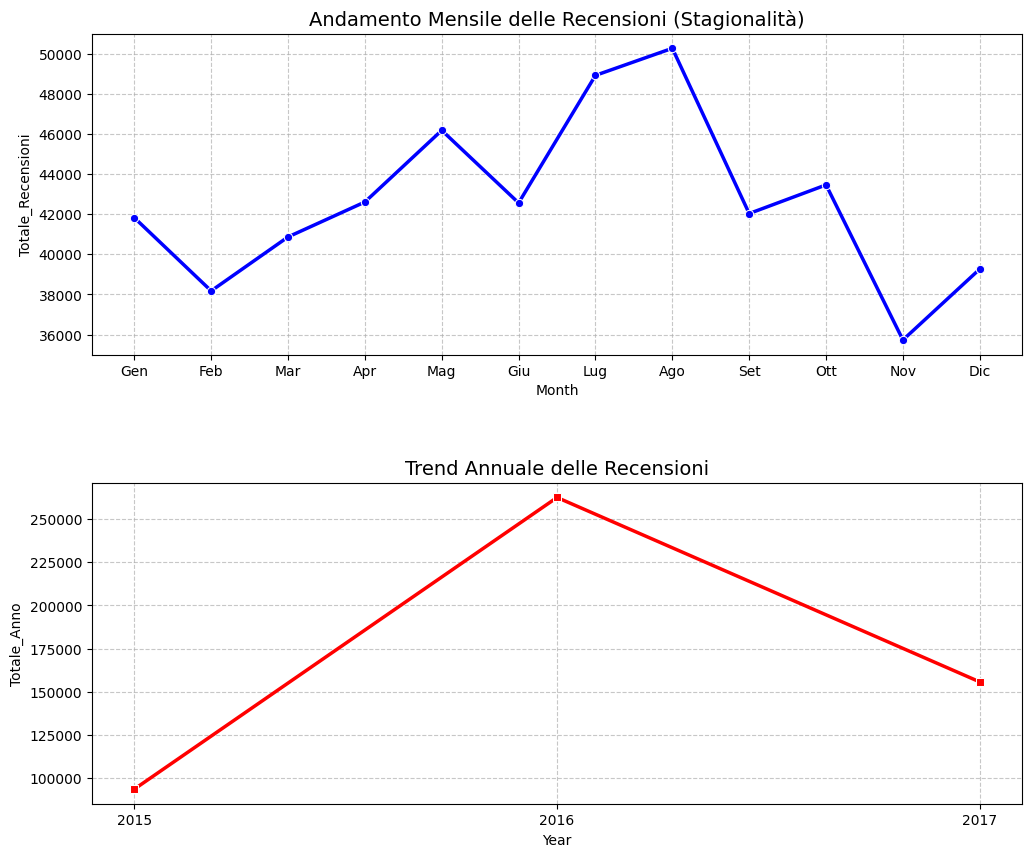

In [ ]:

# Utilizzo HR_mensile e HR_annuale, calcolati in precedenza

# Creazione della figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plt.subplots_adjust(hspace=0.4)

# Grafico 1: Andamento Mensile (Stagionalità)
sns.lineplot(data=HR_mensile, x='Month', y='Totale_Recensioni', 
             marker='o', color='b', ax=ax1, linewidth=2.5)
ax1.set_title('Andamento Mensile delle Recensioni (Stagionalità)', fontsize=14)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic'])
ax1.grid(True, linestyle='--', alpha=0.7)

# Grafico 2: Andamento Annuale (Trend)
# Calcoliamo rapidamente il dato annuale dal DF principale HR
HR_annuale = HR.groupby('Year').size().reset_index(name='Totale_Anno')

sns.lineplot(data=HR_annuale, x='Year', y='Totale_Anno', 
             marker='s', color='r', ax=ax2, linewidth=2.5)
ax2.set_title('Trend Annuale delle Recensioni', fontsize=14)
ax2.set_xticks(HR_annuale['Year'])
ax2.grid(True, linestyle='--', alpha=0.7)

# Salvataggio per il report
plt.savefig('01_lineplot_temporale.png', dpi=300, bbox_inches='tight')
plt.show()



### 2. Bar chart top 10 nazionalità per recensioni


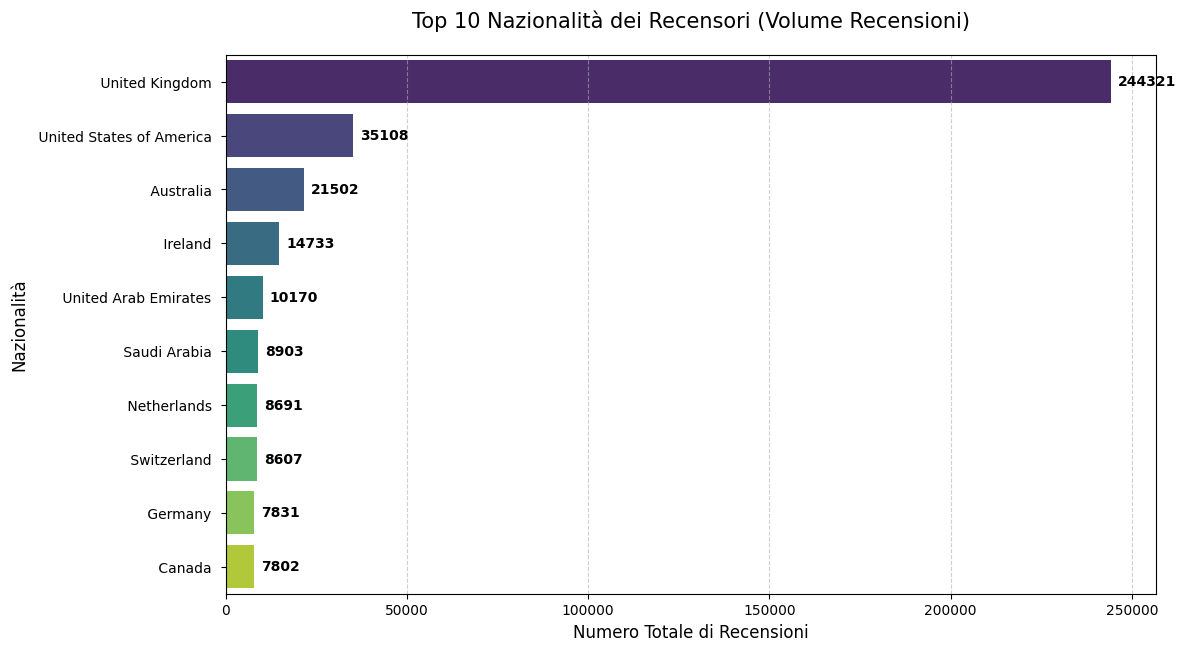

In [40]:

# 1. Rigenerazione dati per il grafico
# Raggruppamento per nazionalità, selezione prime 10 per n. recensioni
HR_top10_nazionalita = HR.groupby('Reviewer_Nationality').size().reset_index(name='Num_Recensioni')
HR_top10_nazionalita = HR_top10_nazionalita.sort_values('Num_Recensioni', ascending=False).head(10)

# 2. CREAZIONE DEL GRAFICO
plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    data=HR_top10_nazionalita, 
    x='Num_Recensioni', 
    y='Reviewer_Nationality', 
    palette='viridis',
    hue='Reviewer_Nationality',
    legend=False
)

# Aggiunta fasce di riferimento sopra le barre
for i in barplot.containers:
    barplot.bar_label(i, padding=5, fontsize=10, fontweight='bold')

plt.title('Top 10 Nazionalità dei Recensori (Volume Recensioni)', fontsize=15, pad=20)
plt.xlabel('Numero Totale di Recensioni', fontsize=12)
plt.ylabel('Nazionalità', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 3. SALVATAGGIO
plt.savefig('02_barchart_top10_nazionalita.png', dpi=300, bbox_inches='tight')
plt.show()



### 3. Bar chart top 10 città per numero recensioni


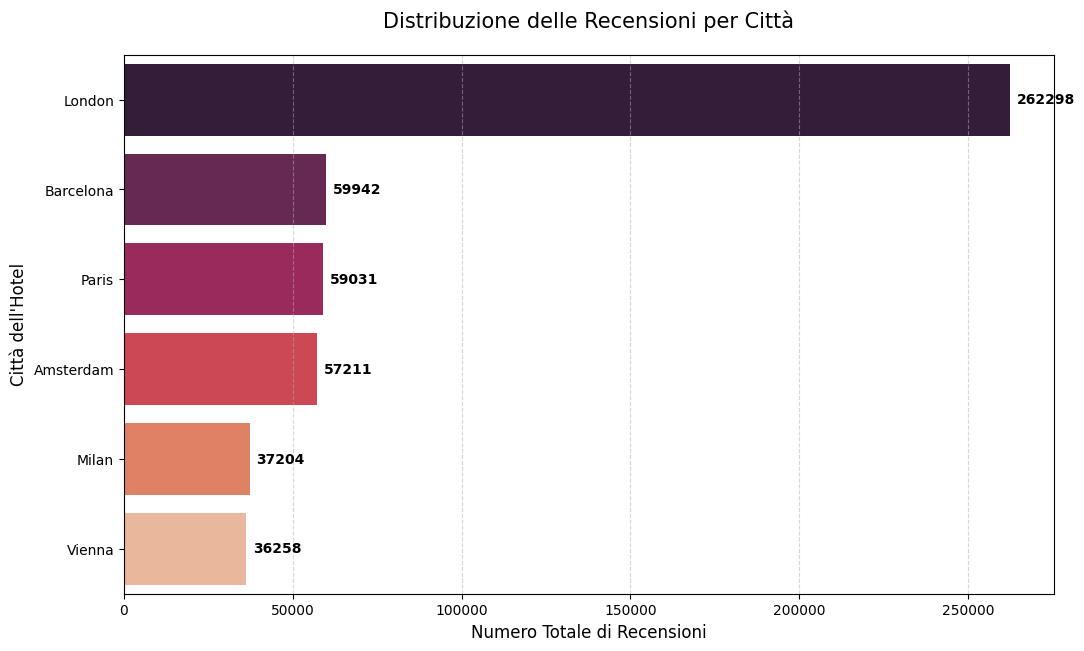

In [52]:

# 1. RIGENERAZIONE DATI PER LE CITTÀ
# Conteggio recensioni per ogni città e ordinamento
HR_citta_count = HR.groupby('Hotel_City').size().reset_index(name='Num_Recensioni')
HR_citta_count = HR_citta_count.sort_values('Num_Recensioni', ascending=False).head(10)

# 2. CREAZIONE DEL GRAFICO
plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    data=HR_citta_count, 
    x='Num_Recensioni', 
    y='Hotel_City', 
    palette='rocket',
    hue='Hotel_City',
    legend=False
)

# Aggiunta dei valori numerici alla fine delle barre
for i in barplot.containers:
    barplot.bar_label(i, padding=5, fontsize=10, fontweight='bold')

# Personalizzazione estetica
plt.title('Distribuzione delle Recensioni per Città', fontsize=15, pad=20)
plt.xlabel('Numero Totale di Recensioni', fontsize=12)
plt.ylabel('Città dell\'Hotel', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 3. SALVATAGGIO
plt.savefig('03_barchart_top_citta.png', dpi=300, bbox_inches='tight')
plt.show()



### 4. Box plot distribuzione Reviewer Score per nazionalità top 3


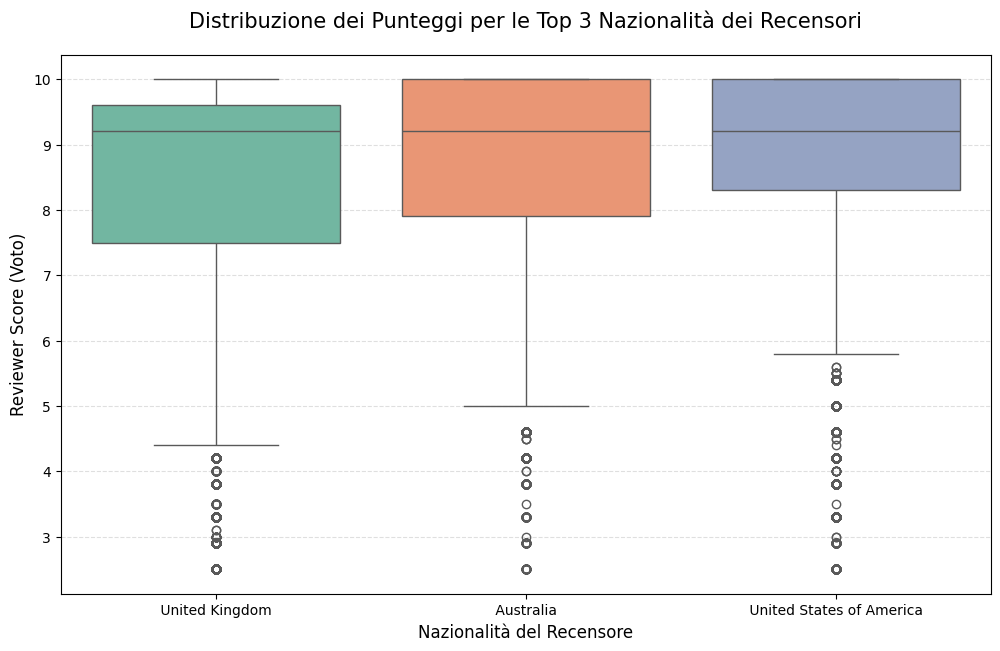

In [42]:

# 1. Identificazione delle top 3 nazionalità dei recensori per volume
top_3_nat = HR['Reviewer_Nationality'].value_counts().nlargest(3).index

# 2. Filtrazione del DataFrame HR per includere solo queste 3 nazionalità
df_top3_box = HR[HR['Reviewer_Nationality'].isin(top_3_nat)]

# 3. Creazione del Box Plot
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_top3_box, 
    x='Reviewer_Nationality', 
    y='Reviewer_Score', 
    palette='Set2',
    hue='Reviewer_Nationality',
    legend=False
)

# Personalizzazione estetica
plt.title('Distribuzione dei Punteggi per le Top 3 Nazionalità dei Recensori', fontsize=15, pad=20)
plt.xlabel('Nazionalità del Recensore', fontsize=12)
plt.ylabel('Reviewer Score (Voto)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Salvataggio per il report
plt.savefig('04_boxplot_score_top3_nazionalita.png', dpi=300, bbox_inches='tight')
plt.show()


### 5. Histogram Review Length per categoria score


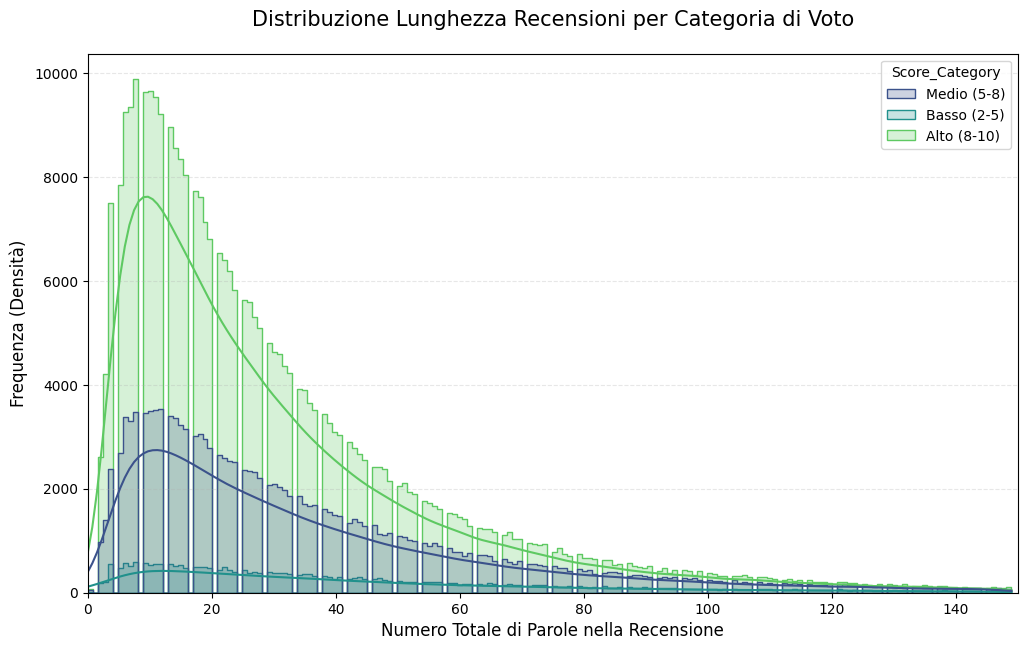

In [54]:

# 1. Calcolo della lunghezza totale della recensione (parole positive + negative)
HR['Total_Review_Word_Count'] = HR['Review_Total_Negative_Word_Counts'] + HR['Review_Total_Positive_Word_Counts']

# 2. Creazione delle categorie per lo Score (es: Basso, Medio, Alto) per un grafico più leggibile
def categorizza_voto(voto):
    if voto <= 5: return 'Basso (2-5)'
    if voto <= 8: return 'Medio (5-8)'
    return 'Alto (8-10)'

HR['Score_Category'] = HR['Reviewer_Score'].apply(categorizza_voto)

# 3. Creazione del grafico (Istogramma con KDE per visualizzazione della densità)
plt.figure(figsize=(12, 7))

# Applicazione limite sulle X (es. 150 parole) onde evitare che il grafico venga schiacciato da pochi lunghissimi commenti
sns.histplot(data=HR[HR['Total_Review_Word_Count'] < 150], 
             x='Total_Review_Word_Count', 
             hue='Score_Category', 
             element='step', 
             kde=True, 
             palette='viridis',
             common_norm=False)

# Personalizzazione estetica
plt.title('Distribuzione Lunghezza Recensioni per Categoria di Voto', fontsize=15, pad=20)
plt.xlabel('Numero Totale di Parole nella Recensione', fontsize=12)
plt.ylabel('Frequenza (Densità)', fontsize=12)
plt.xlim(0, 150) # Limitiamo la vista per chiarezza
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Salvataggio
plt.savefig('05_histogram_review_length.png', dpi=300, bbox_inches='tight')
plt.show()



### La soglia dei 100-120 termini

L'analisi della distribuzione mostra una correlazione inversa tra il punteggio e la verbosità: al crescere della soddisfazione diminuisce la lunghezza del testo, mentre le recensioni negative presentano una distribuzione più dispersa verso conteggi di parole elevati. Oltre le 120 parole, tutte le curve tendono a convergere verso lo zero. Dimostra una soglia psicologica di attenzione: molto raramente un cliente (che sia felice o meno) supera le 150 parole per una recensione d'hotel. 

### 6. Scatter plot Review Length vs Reviewer Score (colore per nazionalità)


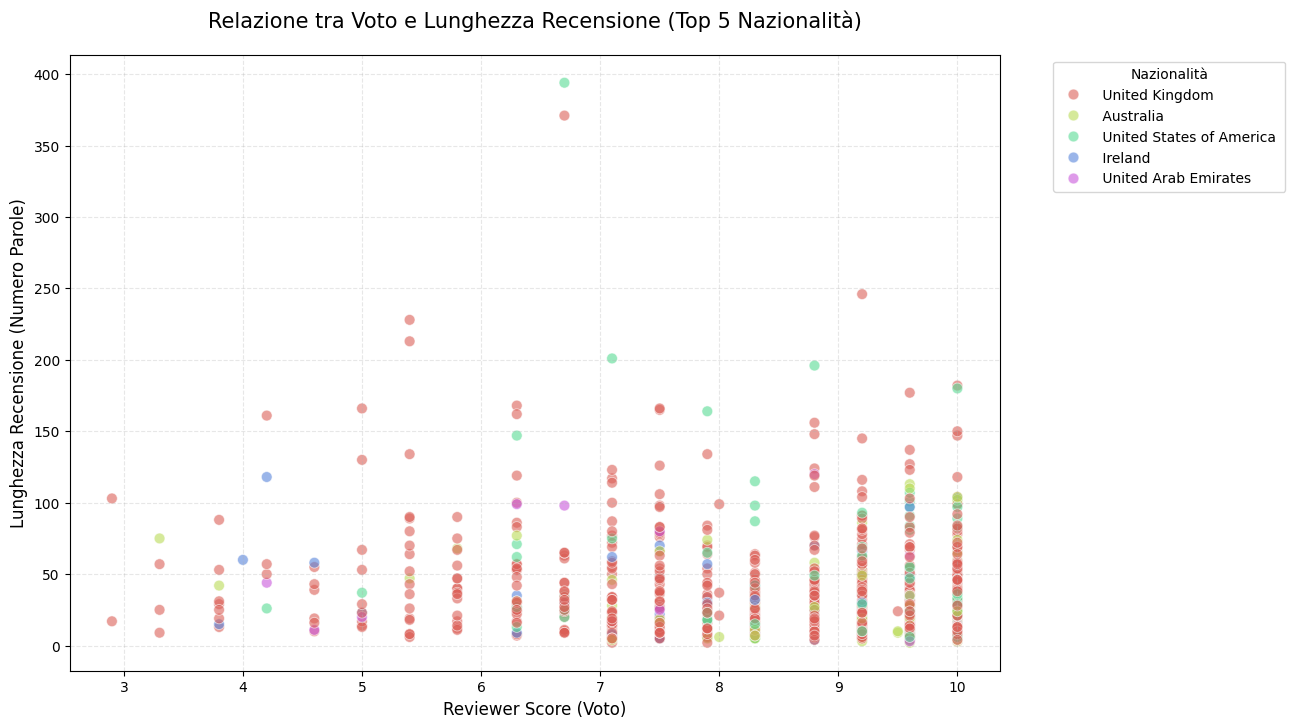

In [63]:

# 1. Preparazione dei dati:
# Utilizzo di un campione casuale di 1000 righe e le top 5 nazionalità per il colore
top_5_countries = HR['Reviewer_Nationality'].value_counts().nlargest(5).index
df_plot = HR[HR['Reviewer_Nationality'].isin(top_5_countries)].sample(1000, random_state=42)

# 2. Creazione dello Scatter Plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot, 
    x='Reviewer_Score', 
    y='Total_Review_Word_Count', 
    hue='Reviewer_Nationality', 
    alpha=0.6,
    palette='hls',
    s=60
)

# 3. Personalizzazione estetica
plt.title('Relazione tra Voto e Lunghezza Recensione (Top 5 Nazionalità)', fontsize=15, pad=20)
plt.xlabel('Reviewer Score (Voto)', fontsize=12)
plt.ylabel('Lunghezza Recensione (Numero Parole)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Nazionalità', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Salvataggio
plt.savefig('06_scatterplot_score_vs_length.png', dpi=300, bbox_inches='tight')
plt.show()


### 7. Bar chart score medio per top 10 città


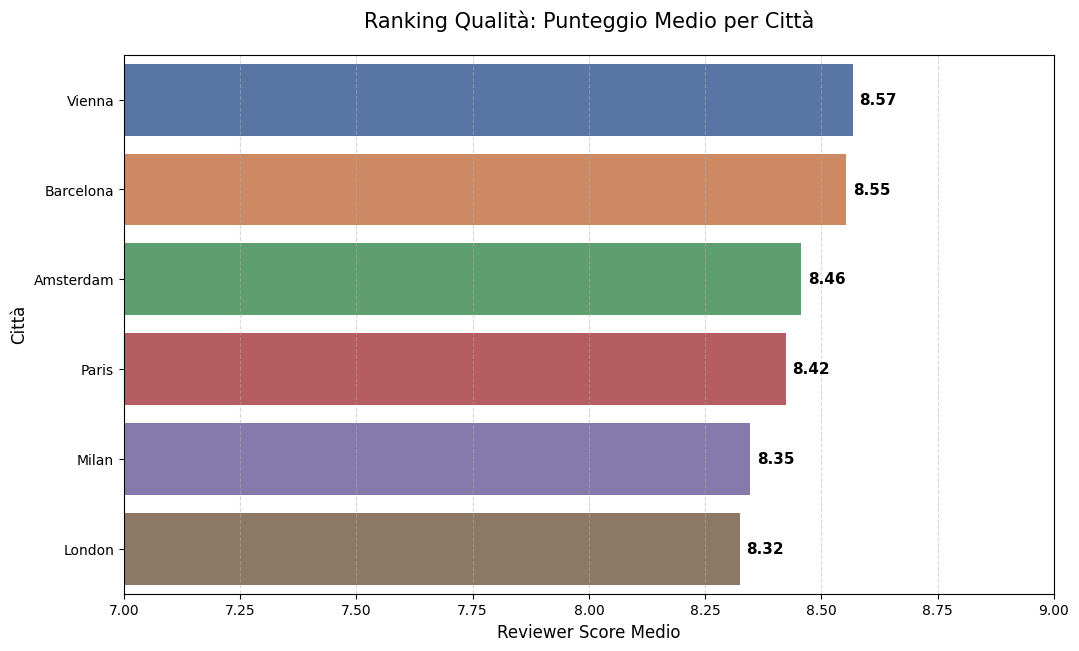

In [56]:

# 1. Preparazione dei dati: calcolo della media punteggio per città
HR_city_score = HR.groupby('Hotel_City')['Reviewer_Score'].mean().reset_index(name='Media_Punteggio')
HR_city_score = HR_city_score.sort_values('Media_Punteggio', ascending=False)

# 2. Creazione del Bar Chart
plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    data=HR_city_score, 
    x='Media_Punteggio', 
    y='Hotel_City', 
    palette='deep',
    hue='Hotel_City',
    legend=False
)

# Aggiunta dei valori numerici precisi sulle barre
for i in barplot.containers:
    barplot.bar_label(i, fmt='%.2f', padding=5, fontsize=11, fontweight='bold')

# Personalizzazione estetica e limiti degli assi
plt.title('Ranking Qualità: Punteggio Medio per Città', fontsize=15, pad=20)
plt.xlabel('Reviewer Score Medio', fontsize=12)
plt.ylabel('Città', fontsize=12)
plt.xlim(7, 9)  # riduzione dell range per evidenziare le differenze tra città
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 3. Salvataggio per il report
plt.savefig('07_barchart_score_citta.png', dpi=300, bbox_inches='tight')
plt.show()


### 8. Heatmap correlazioni numeriche (score, word counts, days since 
review)


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\salma\AppData\Local\Temp\ipykernel_39424\3105010606.py:12: SyntaxWarning: invalid escape sequence '\d'
  days_numeric = HR['days_since_review'].str.extract('(\d+)').astype(float)


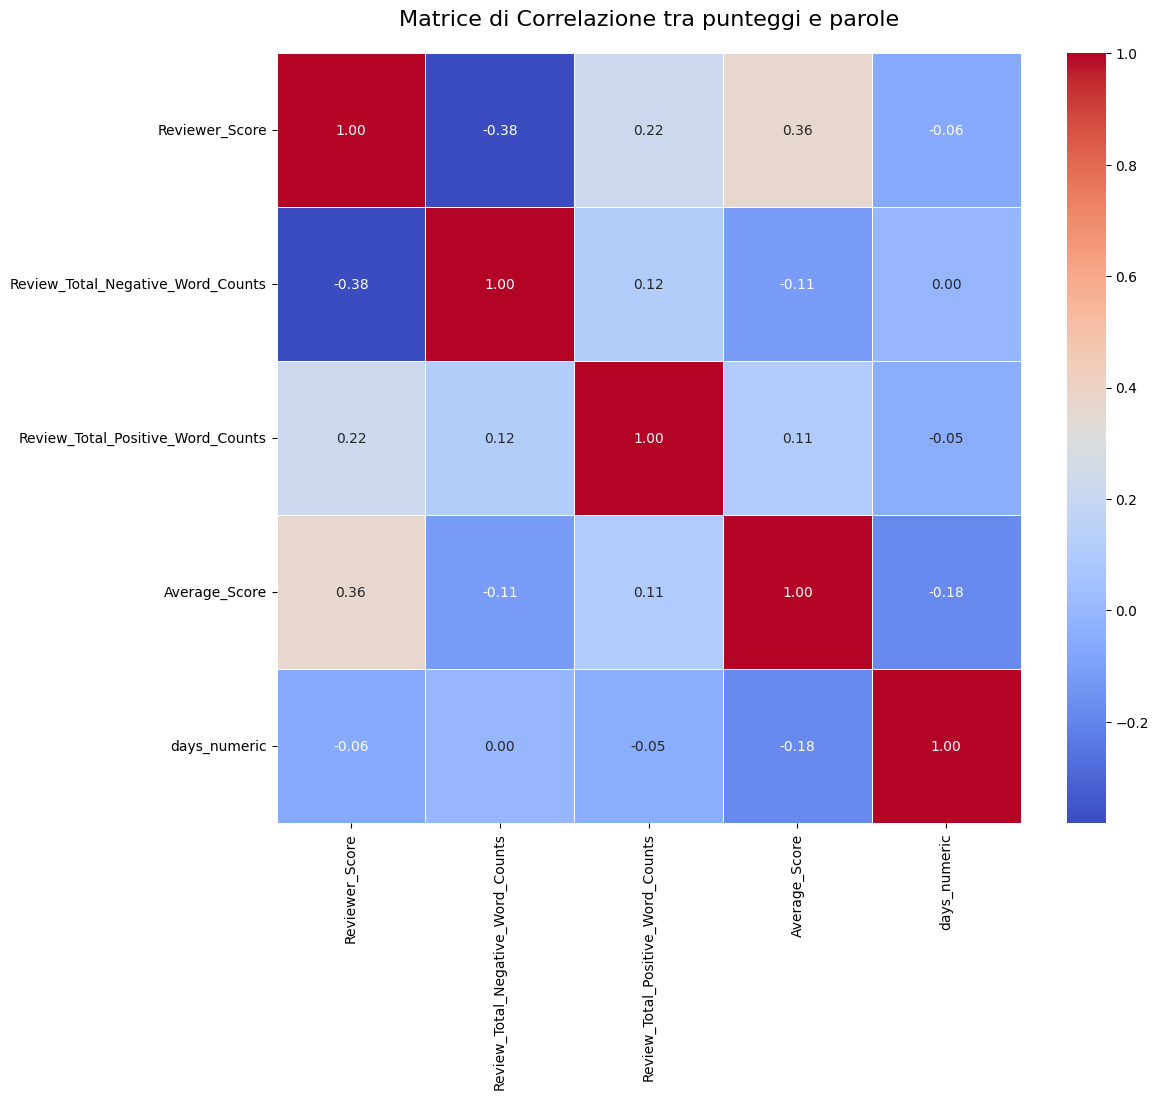

In [62]:

# 1. Definizione della lista delle colonne da analizzare
cols_to_corr = [
    'Reviewer_Score', 
    'Review_Total_Negative_Word_Counts', 
    'Review_Total_Positive_Word_Counts',
    'Average_Score',
    'days_since_review' # La includiamo per poterla trasformare nel passaggio dopo
]

# 2. Creazione della versione temporanea solo per il grafico
temp_corr = HR[cols_to_corr].assign(
    days_numeric = HR['days_since_review'].str.extract('(\d+)').astype(float)
).drop(columns=['days_since_review'])

# 3. Calcolo della correlazione
corr_matrix = temp_corr.corr()

# 4. Generazione Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione tra punteggi e parole', fontsize=16, pad=20)

# 5. Salvataggio
plt.savefig('08_heatmap_correlazione.png', dpi=300, bbox_inches='tight')
plt.show()


La heatmap conferma che la variabile con il maggior impatto negativo sul punteggio è la quantità di testo nelle recensioni negative (-0.38), mentre il tempo trascorso dalla recensione non presenta correlazioni rilevanti con la qualità del feedback.

In [68]:
# CREAZIONE DI UN ULTERIORE GRAFICO(NON RICHIESTO), VALIDO PER UNA RAPIDA VISUALIZZAZIONE A MAGGIORE IMPATTO
# 1. Definizione della funzione per assegnare i colori in base al voto
def assegna_colore(punteggio):
    if punteggio <= 5:
        return 'red'      # Voti bassi
    elif punteggio <= 8:
        return 'orange'   # Voti medi
    else:
        return 'green'    # Voti alti

# 2. Preparazione dati (utilizzando un campione poichè tutto il dataset è troppo grande da rallentare la mappa)
# Selezione casuale di 500 hotel per una visualizzazione fluida
df_mappa = HR.dropna(subset=['lat', 'lng']).sample(n=min(500, len(HR)))

# 3. Creazione di una mappa centrata su una posizione media
map_center = [df_mappa['lat'].mean(), df_mappa['lng'].mean()]
hotel_map = folium.Map(location=map_center, zoom_start=5)

# 4. Aggiunta dei punti sulla mappa
for _, row in df_mappa.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=5,
        popup=f"Hotel: {row['Hotel_Name']}<br>Score: {row['Reviewer_Score']}",
        color=assegna_colore(row['Reviewer_Score']),
        fill=True,
        fill_color=assegna_colore(row['Reviewer_Score']),
        fill_opacity=0.7
    ).add_to(hotel_map)

# 5. Salvataggio della mappa in un file HTML per visualizzarla nel browser
hotel_map.save('09_Distribuzione Geografica della Qualità.html')


Dalla visualizzazione geografica degli hotel, emergono alcune evidenze strategiche che integrano perfettamente i grafici statistici ceati in precedenza, accostando ad essa una valutazione random dei contenuti delle recensioni, si può stabilire quanto segue:

(punti verdi --> voti alti, punti arancioni --> voti medi, punti rossi --> voti bassi)
### 1. La "Macchia Verde" del Centro Storico
Nelle aree centrali e monumentali (il centro di Parigi, la Ringstraße di Vienna, o la City di Londra), appaiono punti prevalentemente verdi. Ciò denota come il valore architettonico e la posizione centrale fungono da "moltiplicatore" della soddisfazione. Anche se la camera potrebbe essere piccola, il cliente tende a dare voti alti per la comodità della posizione.

### 2. I "Cluster Rossi" nelle zone di transito
Spesso i punti rossi (voti bassi) o arancioni tendono a raggrupparsi vicino alle grandi stazioni ferroviarie o nelle zone periferiche.
Infatti, gli hotel in queste zone spesso puntano più sul volume e sul prezzo basso che sulla qualità. Il cliente qui è meno "ammorbidito" dal contesto artistico della città ed è più severo su pulizia e rumore.

### 3. La saturazione di Londra vs l'ordine di Vienna

A Londra, c'è un'altissima densità di punti con un mix caotico di colori. Questo conferma il "Paradosso di Londra": la qualità è imprevedibile anche a pochi metri di distanza.
A Vienna, i punti saranno probabilmente meno densi ma molto più uniformemente verdi/arancioni. Questo visivamente spiega perché è stata classificata come città "Top Excellence".

### 4. Il valore degli Outlier (I punti rossi tra i verdi)
Nel caso ci sia un punto rosso isolato in mezzo a una zona piena di hotel verdi:
possiamo affermare che quella sia una struttura con gravi problemi operativi. La colpa potrebbe non essere della città o della posizione, ma piuttosto della gestione interna. Per un investitore, quello potrebbe essere un caso di studio con lo scopo di non commettere gli stessi errori.



# ANALISI

Dal punto di vista della qualità ricettiva e della risposta dei mercati, l'analisi rivela una geografia della soddisfazione molto interessante:

1. Omogeneità Qualitativa Europea

Nonostante le differenze culturali e architettoniche tra città come Londra, Parigi e Vienna, i punteggi medi rimangono stabilmente sopra l'8.0. Questo indica che le grandi capitali europee analizzate mantengono uno standard di ospitalità "premium" molto coeso. Tuttavia, città come Vienna e Barcellona tendono spesso a mostrare una soddisfazione media leggermente superiore, suggerendo un rapporto qualità-prezzo o un'efficienza dei servizi percepita meglio rispetto alla saturazione di Londra.

2. Il Paradosso di Londra

Londra domina il volume delle recensioni (oltre il 40% del dataset), ma presenta la variabilità più alta nei voti. Questo "rumore" nei dati suggerisce che, a causa dell'altissima densità di hotel, la qualità sia meno prevedibile: si passa dall'eccellenza assoluta a strutture datate che generano le recensioni negative più lunghe e aspre di tutto il campione.

3. Dinamiche Nazionali e Aspettative

Gli ospiti provenienti da nazioni come il Regno Unito (top recensori) mostrano una polarizzazione interessante: sono i più critici quando le aspettative non vengono soddisfatte, ma anche i più costanti nel premiare gli hotel di fascia alta. Al contrario, ospiti di altre nazionalità (es. Australia o USA) tendono a dare voti più alti, probabilmente influenzati dall'entusiasmo per il viaggio intercontinentale, che "ammorbidisce" il giudizio su piccoli difetti strutturali.
4. Il Cluster della Soddisfazione
Il clustering delle città per score ha confermato che la soddisfazione del cliente non è legata al numero di recensioni ricevute (volume), ma alla capacità della città di gestire i picchi stagionali. Le città che mostrano un calo dello score nei mesi di alta stagione (luglio/agosto) sono quelle dove i servizi accessori (colazione, tempi di check-in) soffrono di più il sovraffollamento.

In sintesi, la soddisfazione del cliente in Europa è alta ma estremamente sensibile al sovraffollamento, con le nazioni anglosassoni che fungono da "termometro" critico della qualità del settore.


# CONCLUSIONI E SUGGERIMENTI 
#### PER STRUTTURE INTENZIONATE A MIGLIORARE LA PROPRIA IMMAGINE/QUALITA'/CRESCITA o STRUTTURE IN PROCINTO DI NASCERE:


### 1. Prezzo Dinamico basato sulla Stagionalità
Il Line Plot mensile ha mostrato chiari picchi di recensioni.
Suggerimento: Non limitarsi alla distinzione "Alta/Bassa stagione". Applicare lo Yield Management: alzare i prezzi non solo quando c'è richiesta, ma quando lo Sentiment Index storico della città è alto. Se ad agosto la soddisfazione a Londra cala per il sovraffollamento, un hotel che garantisce standard alti può permettersi un premium price rispetto alla concorrenza "affaticata".
### 2. Differenziazione per "Guest Category"
Dall'analisi dei Tags e delle Nazionalità, è possibile risalire a chi viaggia.
Strategia: Se la nazionalità predominante è quella UK/USA (alto volume), offrendo pacchetti "all-inclusive" (colazione e cancellazione flessibile) a un prezzo superiore. Questi target preferiscono la sicurezza alla parsimonia e, se soddisfatti, lasciano recensioni brevi ma eccellenti che alzano il ranking velocemente.
### 3. Posizionamento tramite "Cluster di Qualità"
Si è evidenziato che alcune città sono "Top Excellence".
Suggerimento: Se si apre in una città a punteggio medio altissimo (es. Vienna), entrare con un prezzo troppo basso (Economy) potrebbe essere percepito come segnale di scarsa qualità. In questi mercati conviene posizionarsi nella fascia Medio-Alta, giustificando il prezzo con servizi efficienti. In questa maniera si potrà evitare recensioni negative, fondamentale nella costruzione di una solida immagine qualitativa. Inoltre, investire su personale multilingua (per il mercato UK/USA).
### 4. Strategia di "Recupero" (Loss Leader)
Tenendo presente il punto 3, si consiglia comunque, nei primi 6 mesi, di mantenere un prezzo del 15% inferiore ai competitor diretti per accumulare velocemente il volume di recensioni necessario a scalare gli algoritmi delle piattaforme (come Booking o TripAdvisor). Una volta raggiunte le prime 100 recensioni con uno Score > 8.5, puoi allineare il prezzo al mercato.
Sintesi per l'investitore: "Il prezzo non deve seguire solo il mercato, ma la capacità di prevenire il dissenso. Un euro investito nel check-in rapido permette di mantenere la tariffa alta anche quando i competitor devono svendere per rimediare a cattive recensioni."
